# Violencia en Tech — Notebook 04: Clasificador por Reglas (Nivel 1)

**Proyecto:** Sistema de Análisis de Violencia Simbólica contra Mujeres en Tecnología  
**Autora:** Maricarmen Camacho Pérez — UAEH, Ciencias Computacionales  
**Input:** `data/processed/reddit_data_limpio.csv`  
**Output:** `data/processed/reddit_data_clasificado_reglas.csv` + `data/processed/reddit_data_balanceado_bert.csv`  

---
**Pipeline:** 01_Extraccion → 02_EDA → 03_Limpieza → **04_Reglas** → 05_BERT → 06_Temporal → Final

---

### ¿Qué hace este notebook?
1. Clasifica cada texto del corpus usando 59 patrones de expresiones regulares
2. Asigna una de tres categorías: VIOLENCIA_DIRECTA, VIOLENCIA_SUTIL o NEUTRAL
3. Genera un dataset balanceado (misma cantidad por clase) para entrenar BERT

### ¿Por qué un clasificador de reglas ANTES de BERT?
- Sirve como **línea base** para comparar contra BERT
- Genera las **etiquetas de entrenamiento** para el ajuste fino de BERT
- Los patrones están basados en la taxonomía de Sue (2010) y Benítez-Eyzaguirre (2021)

### Contexto importante
El corpus proviene de comunidades de apoyo, por lo que la mayoría de los textos  
son **testimoniales** (mujeres contando experiencias), no agresiones directas.

---
## 1. Librerías

In [1]:
# ══════════════════════════════════════════════════════════
# IMPORTACIÓN DE LIBRERÍAS
# ══════════════════════════════════════════════════════════

import pandas as pd          # Manipulación de datos en tablas
import numpy as np           # Operaciones numéricas
import re                    # Expresiones regulares para los patrones de clasificación
import matplotlib.pyplot as plt  # Crear gráficas
import seaborn as sns        # Gráficas estadísticas
from datetime import datetime # Manejo de fechas
from collections import Counter  # Contar frecuencia de palabras
import os                    # Manejar rutas
import warnings

warnings.filterwarnings("ignore")

# Colores por categoría (consistentes en todo el proyecto)
PALETTE = {
    "VIOLENCIA_DIRECTA": "#E84E4F",  # Rojo — violencia explícita
    "VIOLENCIA_SUTIL":   "#F5A623",  # Naranja — microagresiones
    "NEUTRAL":           "#4CAF50",  # Verde — sin violencia
}

# Crear carpeta de imágenes si no existe
os.makedirs("../images/resultados", exist_ok=True)

print(f"Clasificador de reglas iniciado: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Clasificador de reglas iniciado: 2026-03-18 19:48


---
## 2. Cargar datos limpios

In [2]:
# ══════════════════════════════════════════════════════════
# CARGAR EL DATASET LIMPIO DEL NOTEBOOK 03
# ══════════════════════════════════════════════════════════

# Leer el CSV limpio
df = pd.read_csv("../data/processed/reddit_data_limpio.csv")

# Convertir fecha de string a datetime
df["fecha"] = pd.to_datetime(df["fecha"], utc=True, errors="coerce")
df["año"]   = df["fecha"].dt.year  # Asegurar que existe la columna año

# Convertir texto a minúsculas para que los patrones regex funcionen mejor
# El clasificador usa re.IGNORECASE, pero tener todo en minúsculas
# reduce ambigüedades y es más rápido
df["texto"] = df["texto"].fillna("").astype(str).str.lower()

print(f"Dataset cargado: {len(df):,} textos")
print(f"Subreddits: {df['subreddit'].nunique()}")

# ── Diagnóstico rápido: ver vocabulario del corpus ────────
# Revisar las palabras más frecuentes ayuda a entender el tipo de lenguaje
# y a diseñar patrones que coincidan con lo que realmente se escribe
print("\n20 palabras más frecuentes (muestra de 5,000 textos):")
todas_palabras = " ".join(df["texto"].head(5000)).split()  # Juntar textos y separar en palabras
top_palabras = Counter(todas_palabras).most_common(20)      # Las 20 más frecuentes
for palabra, freq in top_palabras:
    print(f"  {palabra:<20} {freq:,}")

Dataset cargado: 184,572 textos
Subreddits: 17

20 palabras más frecuentes (muestra de 5,000 textos):
  to                   18,918
  i                    18,511
  the                  17,749
  and                  16,538
  a                    14,164
  of                   9,418
  that                 8,247
  you                  8,118
  in                   7,541
  it                   6,678
  my                   6,297
  for                  6,088
  is                   6,051
  was                  5,235
  he                   4,354
  with                 4,203
  but                  4,082
  have                 4,030
  this                 3,966
  not                  3,896


---
## 3. Explorar el corpus antes de definir patrones

Buena práctica de data science: primero explorar qué tipo de lenguaje  
se usa en el corpus y DESPUÉS diseñar los patrones de clasificación.

In [3]:
# ══════════════════════════════════════════════════════════
# MUESTRA ALEATORIA DEL CORPUS
# Leer 10 textos al azar para entender el tipo de lenguaje
# que usan las comunidades antes de escribir los patrones
# ══════════════════════════════════════════════════════════

print("MUESTRA DE 10 TEXTOS ALEATORIOS DEL CORPUS")
print("=" * 65)

# .sample(10) toma 10 textos al azar; random_state=42 hace que siempre sean los mismos
muestra = df["texto"].sample(10, random_state=42).tolist()

for i, texto in enumerate(muestra, 1):  # enumerate desde 1 para numerar
    print(f"\n[{i}] {texto[:200]}")     # Solo los primeros 200 caracteres
    print("-" * 65)

MUESTRA DE 10 TEXTOS ALEATORIOS DEL CORPUS

[1] what kind of job offers and interviews are you getting? since this is posted in i assume it's something related?
-----------------------------------------------------------------

[2] i guess it would depend on the various legal issues surrounding your particular access, consent, etc, which i can't really comment on since i don't know those details. on a technical level, supervised
-----------------------------------------------------------------

[3] anytime my peace and mental health are put at risk that is when i would leave. find something else before though because the market right now is very bad . if it means taking a pay cut then by all mea
-----------------------------------------------------------------

[4] thank you! i m determined to get this degree no matter how long it takes, i m already a little behind but i plan to keep pushing through.
-----------------------------------------------------------------

[5] me? i wouldn't 

---
## 4. Definición de patrones de clasificación

Se definen dos listas de expresiones regulares (regex):  
- **28 patrones de violencia directa:** acoso, discriminación, exclusión, insultos  
- **31 patrones de violencia sutil:** mansplaining, microagresiones, condescendencia  

Los patrones se basan en la taxonomía de microagresiones de Sue (2010)  
y en los trabajos sobre cultura brogrammer de Benítez-Eyzaguirre (2021).

In [ ]:
# ══════════════════════════════════════════════════════════
# PATRONES DE VIOLENCIA DIRECTA (28 patrones)
# ══════════════════════════════════════════════════════════
#
# Estos patrones buscan menciones de acoso, discriminación,
# exclusión y agresión explícita. Funcionan tanto para textos
# donde la persona SUFRE la violencia como donde la RELATA.
#
# Sintaxis de regex:
#   r"..."        → string "raw" (las \ no se escapan)
#   .{0,15}       → cualquier carácter, entre 0 y 15 veces (permite palabras en medio)
#   (ed|ing|ment) → alternativas: harassed, harassing, harassment
#   \b            → límite de palabra (evita que "assault" coincida dentro de "assaultrifle")
#   ?             → el carácter anterior es opcional (groped o grope)
# ══════════════════════════════════════════════════════════

PATRONES_VIOLENCIA_DIRECTA = [
    # --- Acoso y agresión física/sexual ---
    r"sexual.{0,15}harass",          # "sexual harassment", "sexually harassed"
    r"harass(ed|ing|ment|er)",       # Cualquier forma de "harassment"
    r"assault(ed|ing|er)?",          # "assault", "assaulted"
    r"groped?",                       # "grope", "groped"
    r"creep(y|ed|ing|s)\b",          # "creepy behavior" (\b evita "creeper" en Minecraft)
    r"stalked?\b",                    # "stalked", "stalk"

    # --- Discriminación explícita de género ---
    r"discriminat(ed|ion|ing)",      # "discrimination", "discriminated"
    r"sexism|sexist",                 # "sexism", "sexist"
    r"misogyn(y|ist|istic)",         # "misogyny", "misogynist"
    r"gender.{0,10}bias",            # "gender bias" (hasta 10 caracteres entre palabras)
    r"gender.{0,10}gap",             # "gender gap"
    r"pay.{0,10}gap",                # "pay gap"

    # --- Exclusión y hostilidad laboral ---
    r"hostile.{0,15}work",           # "hostile work environment"
    r"toxic.{0,10}(culture|workplace|environment|masculinity)",  # "toxic culture", etc.
    r"boys.{0,5}club",               # "boys' club" / "boys club"
    r"old.{0,5}boys",                # "old boys network"
    r"not.{0,10}belong",             # "you don't belong here"
    r"fired.{0,15}(because|for).{0,20}(woman|female|gender|pregnant|maternity)",  # Despido por género
    r"laid.{0,5}off.{0,15}(because|for|being)",  # Despido

    # --- Insultos directos de género ---
    r"\bbitch\b",                     # Insulto directo (\b = solo la palabra completa)
    r"\bslut\b",                      # Insulto sexual
    r"\bwhore\b",                     # Insulto sexual
    r"diversity.{0,5}hire",           # "diversity hire" (deslegitimar contratación)
    r"token.{0,5}(woman|female|girl)",# "token woman" (mujer de adorno)
    r"affirmative.{0,5}action",       # "affirmative action" (usado despectivamente)

    # --- Amenazas y comportamiento agresivo ---
    r"threaten(ed|ing)?",             # "threatened", "threatening"
    r"intimidat(ed|ion|ing)",         # "intimidation", "intimidated"
    r"verbal.{0,5}(abuse|attack)",    # "verbal abuse", "verbal attack"
]

# ══════════════════════════════════════════════════════════
# PATRONES DE VIOLENCIA SUTIL (31 patrones)
# ══════════════════════════════════════════════════════════
#
# Microagresiones, mansplaining, condescendencia, cuestionamiento
# velado de competencia, estereotipos de género implícitos.
# Basados en la taxonomía de Sue (2010) sobre microagresiones.
# ══════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════
# PATRONES DE VIOLENCIA SUTIL (45 patrones) 
# ══════════════════════════════════════════════════════════
#
#  La gente no escribe "mansplained to me",
# escribe "he kept explaining my own code to me".
#
# Se agrega patrones más amplios que capturan cómo la gente
# REALMENTE describe las microagresiones en Reddit.
# ══════════════════════════════════════════════════════════

PATRONES_VIOLENCIA_SUTIL = [

    # ── Dudas sobre competencia por género ───────────────
    # Cuestionamiento velado de las capacidades de una mujer
    r"(not|didn.t).{0,15}take.{0,10}(me|her|us).{0,10}serious",       # "not taken seriously"
    r"questioned?.{0,10}(my|her).{0,10}(competence|skills|knowledge|ability|expertise)",
    r"assumed?.{0,15}(i|she).{0,10}(wasn.t|couldn.t|didn.t).{0,10}(know|code|program|understand)",
    r"(didn.t|don.t).{0,10}look.{0,10}like.{0,15}(engineer|developer|programmer|coder)",
    r"are.{0,5}you.{0,10}sure.{0,10}(you|she).{0,10}(know|understand|can)",
    r"impressive.{0,10}for.{0,5}(a|the).{0,5}(woman|girl|female)",
    r"(good|great|smart|capable).{0,10}for.{0,5}(a|the).{0,5}(woman|girl|female)",
    r"(surprisingly|unexpectedly).{0,10}(good|smart|capable|technical|competent)",

    # ── Mansplaining y condescendencia ───────────────────
    r"mansplain(ed|ing|er|s)?",                                         # Cualquier forma
    r"condescend(ing|ed|ingly)",
    r"patroniz(ing|ed|ingly)",
    r"talked?.{0,5}down.{0,5}to.{0,5}(me|her|us)",
    r"explain(ed|ing).{0,20}(already knew|i know|she know|my own)",     # "explained my own code to me"
    r"(he|guy|man|male|coworker|colleague|boss).{0,20}explain(ed|ing).{0,15}(to me|to her)",  # NUEVO
    r"(let|allow).{0,5}me.{0,5}explain",
    r"well,?.{0,3}actually",

    # ── Microagresiones e invisibilización ───────────────
    r"microaggress(ion|ions|ive)",
    r"credit(ed)?.{0,15}(idea|work|contribution).{0,15}(man|guy|he|male)",
    r"(stole?|took?|claimed?).{0,15}(my|her).{0,15}(idea|credit|work)",
    r"talked?.{0,10}over",
    r"interrupt(ed|ing|s).{0,10}(me|her|women|constantly|always)",      # Ampliado
    r"ignored?.{0,15}(my|her).{0,15}(comment|suggestion|idea|input|opinion|voice)",

    # ── Síndrome del impostor inducido ───────────────────
    r"imposter.{0,5}syndrome",
    r"impostor.{0,5}syndrome",
    r"(made|make|makes).{0,10}(me|her).{0,10}feel.{0,10}(stupid|incompetent|inferior|less|dumb|small)",
    r"(feel|felt).{0,10}(like a fraud|like i don.t belong|out of place|unwelcome)",  # NUEVO

    # ── Estereotipos de género en tech ───────────────────
    r"(women|girls|females).{0,10}(are|were|aren.t).{0,15}(good|suited|built|wired|meant).{0,10}(for|to).{0,10}(tech|coding|programming|stem)",
    r"(women|girls|females).{0,10}(don.t|can.t|shouldn.t|won.t).{0,10}(code|program|hack|do tech)",
    r"not.{0,5}(technical|a technical).{0,5}(person|type|enough)",
    r"too.{0,5}emotional.{0,10}(for|to).{0,10}(work|code|program|tech|this)",

    # ── Exclusión social/laboral sutil ───────────────────
    r"left.{0,10}out.{0,10}(of|from).{0,10}(meeting|discussion|team|group|conversation)",
    r"(only|sole|single).{0,5}(woman|female|girl).{0,5}(in|on|at)",
    r"excluded?.{0,15}(because|for|being).{0,15}(woman|female|gender)",

    # ══════════════════════════════════════════════════════
    # MÁS PATRONES 
    # ══════════════════════════════════════════════════════

    # ── Roles de género asumidos en el trabajo ───────────
    # "They assumed I was the secretary / HR / the assistant"
    r"assumed?.{0,15}(i|she).{0,10}(was|were).{0,10}(the )?(secretary|assistant|receptionist|hr|intern|note.?taker)",
    # "Asked me to take notes / get coffee / order lunch"
    r"(asked|told|expected|made).{0,10}(me|her).{0,10}(to )?(take notes|get coffee|order (lunch|food)|clean|organize|plan the party)",
    # "Office housework" — tareas no técnicas asignadas por género
    r"office.{0,5}housework",

    # ── Comentarios sobre apariencia ─────────────────────
    # "Told me to smile more" / "Asked her to wear makeup"
    r"(told|asked|said).{0,10}(me|her|to).{0,10}(smile|wear.{0,5}(makeup|make.up|heels|dress))",
    # "Commented on what I was wearing" / "dress more feminine"
    r"(comment|remark).{0,10}(on|about).{0,10}(what i|how i|her).{0,10}(wear|dress|look)",
    r"dress.{0,5}(more|less).{0,5}(feminine|professional|sexy|girly)",

    # ── Ser pasada por alto / no escuchada ───────────────
    # "I said something and nobody listened, then a guy said the same thing and everyone agreed"
    r"(said|suggested).{0,10}(the same|something).{0,15}(guy|man|he|male).{0,15}(said|repeated|got credit)",
    # "Passed over for promotion" / "overlooked for the role"
    r"(passed over|overlooked|skipped).{0,10}(for).{0,10}(promotion|raise|role|lead|opportunity)",
    # "They always ask the men first"
    r"(always|never).{0,10}(ask|include|invite|consider).{0,10}(me|her|women|the women)",

    # ── Doble estándar ───────────────────────────────────
    # "When a man does it he's assertive, when I do it I'm aggressive/bossy/difficult"
    r"(when.{0,5}(a man|he|men|guys).{0,20}(assertive|leader|confident)).{0,20}(when.{0,5}(i|she|women).{0,20}(bossy|aggressive|difficult|bitchy|emotional))",
    # Versión más simple: "called bossy/aggressive/difficult for..."
    r"(called|labeled|seen as).{0,10}(bossy|aggressive|difficult|bitchy|emotional|dramatic|hysterical).{0,10}(for|when|because)",
    # "Too aggressive for a woman"
    r"too.{0,5}(aggressive|assertive|ambitious|loud|direct).{0,10}(for a|as a).{0,5}(woman|girl|female)",

    # ── Cultura bro / exclusión social ───────────────────
    # "Bro culture" / "boys club" / "locker room talk"
    r"bro.{0,3}culture",
    r"locker.{0,3}room",
]

# ══════════════════════════════════════════════════════════
# COMPILAR PATRONES
# re.compile() convierte cada string en un objeto regex listo para usar.
# Esto es más rápido que compilar cada vez que se busca.
# re.IGNORECASE hace que no distinga mayúsculas/minúsculas.
# ══════════════════════════════════════════════════════════

REGEX_DIRECTA = [re.compile(p, re.IGNORECASE) for p in PATRONES_VIOLENCIA_DIRECTA]
REGEX_SUTIL   = [re.compile(p, re.IGNORECASE) for p in PATRONES_VIOLENCIA_SUTIL]

print(f"Patrones de violencia directa : {len(PATRONES_VIOLENCIA_DIRECTA)}")
print(f"Patrones de violencia sutil   : {len(PATRONES_VIOLENCIA_SUTIL)}")
print(f"Total de patrones             : {len(PATRONES_VIOLENCIA_DIRECTA) + len(PATRONES_VIOLENCIA_SUTIL)}")

# ── Test con frases de ejemplo ───────────────────────────
# Verificar que los patrones detectan correctamente diferentes tipos de texto
print("\nTest con frases representativas:")
print("-" * 60)

test_frases = [
    "i was sexually harassed by my manager at the tech company",       # → DIRECTA
    "she faced discrimination when she applied for the senior role",   # → DIRECTA
    "my coworker mansplained the algorithm i built to me",             # → SUTIL
    "they questioned my competence just because im a woman",           # → SUTIL
    "well actually let me explain how this function works",            # → SUTIL
    "i was the only woman on the team and felt constantly excluded",   # → SUTIL
    "how do i implement a binary search tree in python",               # → NEUTRAL
    "just got promoted to senior engineer after 3 years",              # → NEUTRAL
]

for frase in test_frases:
    # Contar cuántos patrones coinciden en cada categoría
    score_d = sum(1 for r in REGEX_DIRECTA if r.search(frase))  # Patrones directos que coinciden
    score_s = sum(1 for r in REGEX_SUTIL   if r.search(frase))  # Patrones sutiles que coinciden
    # Asignar categoría con prioridad: directa > sutil > neutral
    if score_d > 0:
        cat = "VIOLENCIA_DIRECTA"
    elif score_s > 0:
        cat = "VIOLENCIA_SUTIL"
    else:
        cat = "NEUTRAL"
    print(f"  [{cat:<22}] {frase[:65]}")

Patrones de violencia directa : 28
Patrones de violencia sutil   : 47
Total de patrones             : 75

Test con frases representativas:
------------------------------------------------------------
  [VIOLENCIA_DIRECTA     ] i was sexually harassed by my manager at the tech company
  [VIOLENCIA_DIRECTA     ] she faced discrimination when she applied for the senior role
  [VIOLENCIA_SUTIL       ] my coworker mansplained the algorithm i built to me
  [VIOLENCIA_SUTIL       ] they questioned my competence just because im a woman
  [VIOLENCIA_SUTIL       ] well actually let me explain how this function works
  [VIOLENCIA_SUTIL       ] i was the only woman on the team and felt constantly excluded
  [NEUTRAL               ] how do i implement a binary search tree in python
  [NEUTRAL               ] just got promoted to senior engineer after 3 years


---
## 5. Clasificar el corpus completo

In [5]:
# ══════════════════════════════════════════════════════════
# FUNCIÓN DE CLASIFICACIÓN
# Recibe un texto y lo clasifica usando los patrones regex
# ══════════════════════════════════════════════════════════

def clasificar_texto(texto):
    """
    Clasifica un texto en una de tres categorías usando expresiones regulares.
    
    Lógica:
    1. Contar cuántos patrones de violencia directa coinciden
    2. Contar cuántos patrones de violencia sutil coinciden
    3. Si coincide al menos 1 patrón directo → VIOLENCIA_DIRECTA
    4. Si no, pero coincide al menos 1 sutil → VIOLENCIA_SUTIL
    5. Si no coincide ninguno → NEUTRAL
    
    Prioridad: DIRECTA > SUTIL > NEUTRAL
    (si un texto tiene ambas, se clasifica como directa porque es más grave)
    
    Parámetros:
        texto (str): texto limpio a clasificar
    Retorna:
        dict con 'categoria', 'score_directa' y 'score_sutil'
    """
    # Textos vacíos o muy cortos → NEUTRAL automáticamente
    if not texto or len(texto.split()) < 3:
        return {"categoria": "NEUTRAL", "score_directa": 0, "score_sutil": 0}

    # Contar cuántos patrones de cada tipo coinciden con el texto
    # r.search(texto) retorna un match si el patrón aparece en cualquier parte del texto
    score_d = sum(1 for r in REGEX_DIRECTA if r.search(texto))  # Patrones directos
    score_s = sum(1 for r in REGEX_SUTIL   if r.search(texto))  # Patrones sutiles

    # Asignar categoría con prioridad
    if score_d >= 1:       # Al menos 1 patrón directo
        cat = "VIOLENCIA_DIRECTA"
    elif score_s >= 1:     # Al menos 1 patrón sutil
        cat = "VIOLENCIA_SUTIL"
    else:                  # Ningún patrón coincidió
        cat = "NEUTRAL"

    return {"categoria": cat, "score_directa": score_d, "score_sutil": score_s}


# ══════════════════════════════════════════════════════════
# APLICAR CLASIFICACIÓN A TODO EL CORPUS
# ══════════════════════════════════════════════════════════

print(f"Clasificando {len(df):,} textos...")

# Aplicar la función a cada texto → devuelve una Serie de diccionarios
resultados = df["texto"].apply(clasificar_texto)

# Extraer cada campo del diccionario en columnas separadas
df["categoria_reglas"] = resultados.apply(lambda x: x["categoria"])      # La etiqueta
df["score_directa"]    = resultados.apply(lambda x: x["score_directa"])  # Cuántos patrones directos
df["score_sutil"]      = resultados.apply(lambda x: x["score_sutil"])    # Cuántos patrones sutiles

# ── Mostrar distribución resultante ──────────────────────
print("\nDistribución de categorías:")
print("-" * 50)
dist = df["categoria_reglas"].value_counts()  # Contar textos por categoría
total = len(df)
for cat, n in dist.items():
    barra = "█" * int(n / total * 40)  # Barra visual proporcional
    print(f"  {cat:<22} {n:>8,}  ({n/total*100:.1f}%)  {barra}")
print(f"  {'TOTAL':<22} {total:>8,}  (100.0%)")

Clasificando 184,572 textos...

Distribución de categorías:
--------------------------------------------------
  NEUTRAL                 167,214  (90.6%)  ████████████████████████████████████
  VIOLENCIA_DIRECTA        12,663  (6.9%)  ██
  VIOLENCIA_SUTIL           4,695  (2.5%)  █
  TOTAL                   184,572  (100.0%)


---
## 6. Verificar clasificación con ejemplos

In [ ]:
# ══════════════════════════════════════════════════════════
# VERIFICACIÓN MANUAL DE LA CLASIFICACIÓN
# Mostrar ejemplos de cada categoría para confirmar que los
# patrones están funcionando correctamente
# ══════════════════════════════════════════════════════════

# ── Ejemplos de VIOLENCIA DIRECTA ────────────────────────
print("VIOLENCIA_DIRECTA — 5 ejemplos:")
print("-" * 60)
vd = df[df["categoria_reglas"] == "VIOLENCIA_DIRECTA"]  # Filtrar solo directa
for _, row in vd.head(5).iterrows():  # Tomar los primeros 5
    print(f"  Score: {row['score_directa']} | {row['texto'][:150]}")  # Mostrar score + texto
    print()

# ── Ejemplos de VIOLENCIA SUTIL ──────────────────────────
print("VIOLENCIA_SUTIL — 5 ejemplos:")
print("-" * 60)
vs = df[df["categoria_reglas"] == "VIOLENCIA_SUTIL"]
for _, row in vs.head(5).iterrows():
    print(f"  Score: {row['score_sutil']} | {row['texto'][:150]}")
    print()

# ── Ejemplos de NEUTRAL ──────────────────────────────────
# Es importante verificar que los neutrales realmente no tienen violencia
# 
print("NEUTRAL — 5 ejemplos (verificar que no son falsos negativos):")
print("-" * 60)
ne = df[df["categoria_reglas"] == "NEUTRAL"]
for _, row in ne.sample(5, random_state=7).iterrows():  # 5 aleatorios
    print(f"  {row['texto'][:150]}")
    print()

VIOLENCIA_DIRECTA — 5 ejemplos:
------------------------------------------------------------
  Score: 1 | if they have a corporate office i would call and complain. leave reviews. post on social. shout it from the rooftops. everyone needs to know that this

  Score: 2 | my creepy older male neighbor whom i've been avoiding reported me missing when he didn't see me for two days. update: (and below in comments). x200b; 

  Score: 2 | if you are in the us there s a thing called vawa. the violence against women act. your landlord has to let you out of the lease if you are being abuse

  Score: 1 | inform your landlord that you are now looking to move also. this person has made the unit unlivable and you will be breaking your lease due to him all

  Score: 3 | i had my own creepy neighbor. he'd watch me whenever i went outside and linger outside my apartment. his parking spot was under my window (2nd story p

VIOLENCIA_SUTIL — 5 ejemplos:
----------------------------------------------------

---
## 7. Visualización de resultados

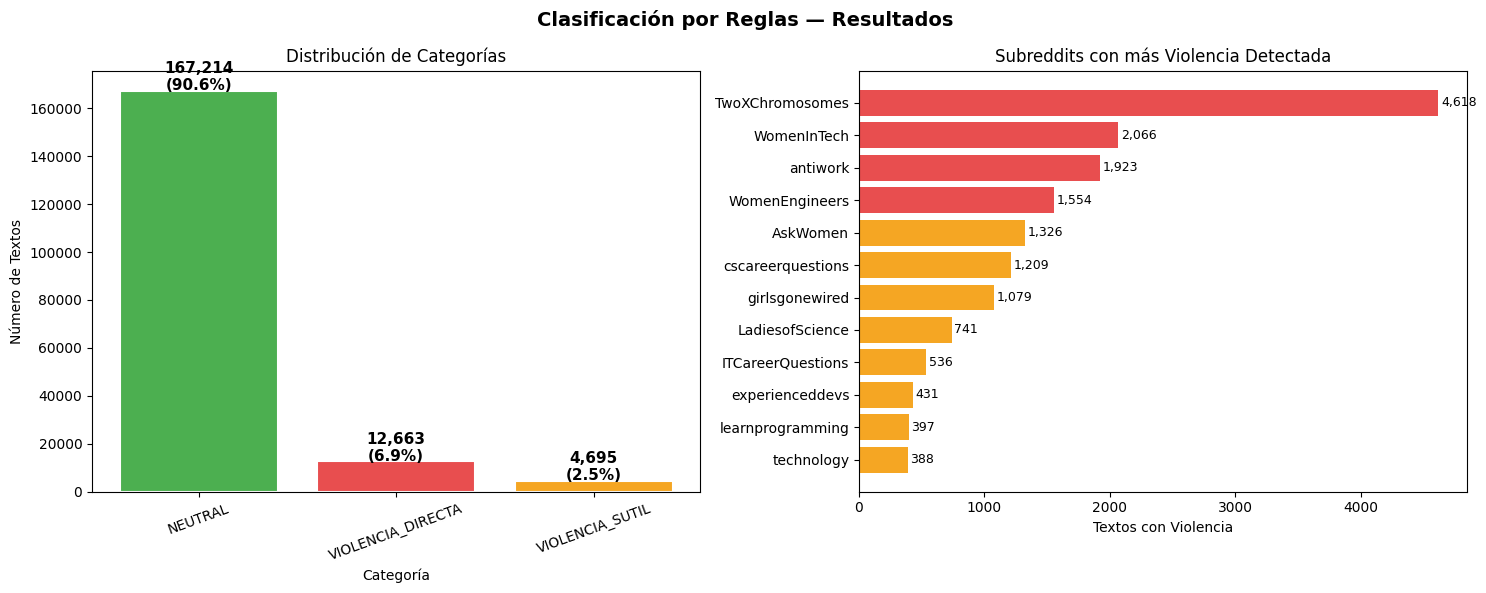

Figura guardada: ../images/resultados/04_clasificacion_reglas.png


In [9]:
# ══════════════════════════════════════════════════════════
# GRÁFICAS DE RESULTADOS DEL CLASIFICADOR DE REGLAS
# 2 paneles: distribución de categorías + top subreddits con violencia
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Clasificación por Reglas — Resultados", fontsize=14, fontweight="bold")

# Distribución de categorías
dist = df["categoria_reglas"].value_counts()
colores = [PALETTE.get(c, "#999") for c in dist.index]  # Color según categoría

# ── Panel izquierdo: barras por categoría ────────────────
ax = axes[0]
bars = ax.bar(dist.index, dist.values,
              color=colores, edgecolor="white", linewidth=1.5)
ax.set_title("Distribución de Categorías")
ax.set_ylabel("Número de Textos")
ax.set_xlabel("Categoría")
ax.tick_params(axis="x", rotation=20)  # Rotar etiquetas para que no se encimen

# Poner número + porcentaje encima de cada barra
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 200,
            f"{h:,}\n({h/len(df)*100:.1f}%)",
            ha="center", fontsize=11, fontweight="bold")

# ── Panel derecho: top 12 subreddits con más violencia ───
ax = axes[1]

# Contar textos con violencia (directa + sutil) por subreddit
viol_por_sub = (
    df[df["categoria_reglas"] != "NEUTRAL"]  # Solo textos con violencia
    .groupby("subreddit").size()              # Contar por subreddit
    .sort_values(ascending=False)             # Ordenar de mayor a menor
    .head(12)                                 # Top 12
)

# Los 4 primeros en rojo, el resto en naranja
colores_sub = ["#E84E4F" if i < 4 else "#F5A623" for i in range(len(viol_por_sub))]

ax.barh(range(len(viol_por_sub)), viol_por_sub.values, color=colores_sub)
ax.set_yticks(range(len(viol_por_sub)))
ax.set_yticklabels(viol_por_sub.index)
ax.set_title("Subreddits con más Violencia Detectada")
ax.set_xlabel("Textos con Violencia")
ax.invert_yaxis()  # El más grande arriba

# Poner número al final de cada barra
for i, v in enumerate(viol_por_sub.values):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9)

# Guardar
plt.tight_layout()
ruta_fig = "../images/resultados/04_clasificacion_reglas.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig}")

---
## 8. Guardar datasets para BERT

Se generan dos archivos:
1. **Dataset completo clasificado:** todos los textos con su etiqueta de reglas
2. **Dataset balanceado para BERT:** misma cantidad de cada clase para entrenamiento

In [ ]:
# ══════════════════════════════════════════════════════════
# GUARDAR DATASET COMPLETO CLASIFICADO
# Todos los textos del corpus con su etiqueta de reglas
# ══════════════════════════════════════════════════════════

ruta_completo = "../data/processed/reddit_data_clasificado_reglas.csv"
df.to_csv(ruta_completo, index=False)
print(f"Dataset completo: {ruta_completo} ({len(df):,} registros)")

# ══════════════════════════════════════════════════════════
# CREAR DATASET BALANCEADO PARA ENTRENAR BERT
# ══════════════════════════════════════════════════════════
#
# ¿Por qué balancear?
# Si se le da a BERT 150,000 textos neutrales y 5,000 de violencia,
# va a aprender que "todo es neutral" porque es lo más fácil.
# Al balancear, le damos la misma cantidad de cada clase para que
# aprenda a distinguir bien las tres categorías.

# Ver cuántos textos hay de cada categoría
dist = df["categoria_reglas"].value_counts()
print(f"\nDistribución antes de balancear:")
for cat, n in dist.items():
    print(f"  {cat:<22} : {n:,}")

# La clase con menos textos determina el tamaño
# (no podemos tener más muestras de las que existen sin repetir)
min_clase = dist.min()  # La clase más pequeña
MUESTRAS_POR_CLASE = max(min_clase, 500)  # Mínimo 500 (por si alguna clase es muy chica)
print(f"\nMuestras por clase para BERT: {MUESTRAS_POR_CLASE:,}")

# Tomar MUESTRAS_POR_CLASE textos de cada categoría
partes = []
for categoria, grupo in df.groupby("categoria_reglas"):
    n = min(MUESTRAS_POR_CLASE, len(grupo))  # No tomar más de los que hay
    reemplazar = len(grupo) < MUESTRAS_POR_CLASE  # Si hay menos, repetir (oversampling)
    muestra = grupo.sample(n=n, replace=reemplazar, random_state=42)
    partes.append(muestra)

# Juntar las tres muestras en un solo DataFrame
df_bal = pd.concat(partes, ignore_index=True)

# Mezclar aleatoriamente (groupby los pone en bloques)
# frac=1 significa "tomar el 100% pero en orden aleatorio"
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)

# Mostrar distribución balanceada
print(f"\nDistribución después de balancear:")
for cat, n in df_bal["categoria_reglas"].value_counts().items():
    print(f"  {cat:<22} : {n:,}")
print(f"  {'TOTAL':<22} : {len(df_bal):,}")

# Guardar
ruta_bal = "../data/processed/reddit_data_balanceado_bert.csv"
df_bal.to_csv(ruta_bal, index=False)

# ── Resumen final ────────────────────────────────────────
print("\n" + "=" * 55)
print("RESUMEN — NOTEBOOK 04: CLASIFICACIÓN POR REGLAS")
print("=" * 55)
print(f"  Patrones directos    : {len(PATRONES_VIOLENCIA_DIRECTA)}")
print(f"  Patrones sutiles     : {len(PATRONES_VIOLENCIA_SUTIL)}")
print(f"  Total patrones       : {len(PATRONES_VIOLENCIA_DIRECTA) + len(PATRONES_VIOLENCIA_SUTIL)}")
print(f"  Corpus clasificado   : {len(df):,} textos")
print(f"  Dataset balanceado   : {len(df_bal):,} textos ({MUESTRAS_POR_CLASE:,} por clase)")
print(f"  Archivos generados   :")
print(f"    {ruta_completo}")
print(f"    {ruta_bal}")
print("=" * 55)
print("\n→ Siguiente paso: notebooks/05_BERT_Colab.ipynb")

Dataset completo: ../data/processed/reddit_data_clasificado_reglas.csv (184,572 registros)

Distribución antes de balancear:
  NEUTRAL                : 167,214
  VIOLENCIA_DIRECTA      : 12,663
  VIOLENCIA_SUTIL        : 4,695

Muestras por clase para BERT: 4,695

Distribución después de balancear:
  NEUTRAL                : 4,695
  VIOLENCIA_DIRECTA      : 4,695
  VIOLENCIA_SUTIL        : 4,695
  TOTAL                  : 14,085

RESUMEN — NOTEBOOK 04: CLASIFICACIÓN POR REGLAS
  Patrones directos    : 28
  Patrones sutiles     : 47
  Total patrones       : 75
  Corpus clasificado   : 184,572 textos
  Dataset balanceado   : 14,085 textos (4,695 por clase)
  Archivos generados   :
    ../data/processed/reddit_data_clasificado_reglas.csv
    ../data/processed/reddit_data_balanceado_bert.csv

→ Siguiente paso: notebooks/05_BERT_Colab.ipynb
